In [124]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

DOSSIER_CALIBRATION = "chess/*.jpg"
PHOTO_1             = "7.jpg"
PHOTO_2             = "8.jpg"
BASELINE            = 15.0   
TAILLE_CASE         = 2.0    
NB_COINS_X          = 7      
NB_COINS_Y          = 9      
SHRINK_CALIB        = 0.3    # facteur de redimensionnement pour la calibration
SHRINK_STEREO       = 0.8    # facteur de redimensionnement pour les photos stereo



---
## Cellule 2 — Étape 1 : Calibration de la caméra



44 images de calibration trouvees
Damier detecte dans 43/44 images


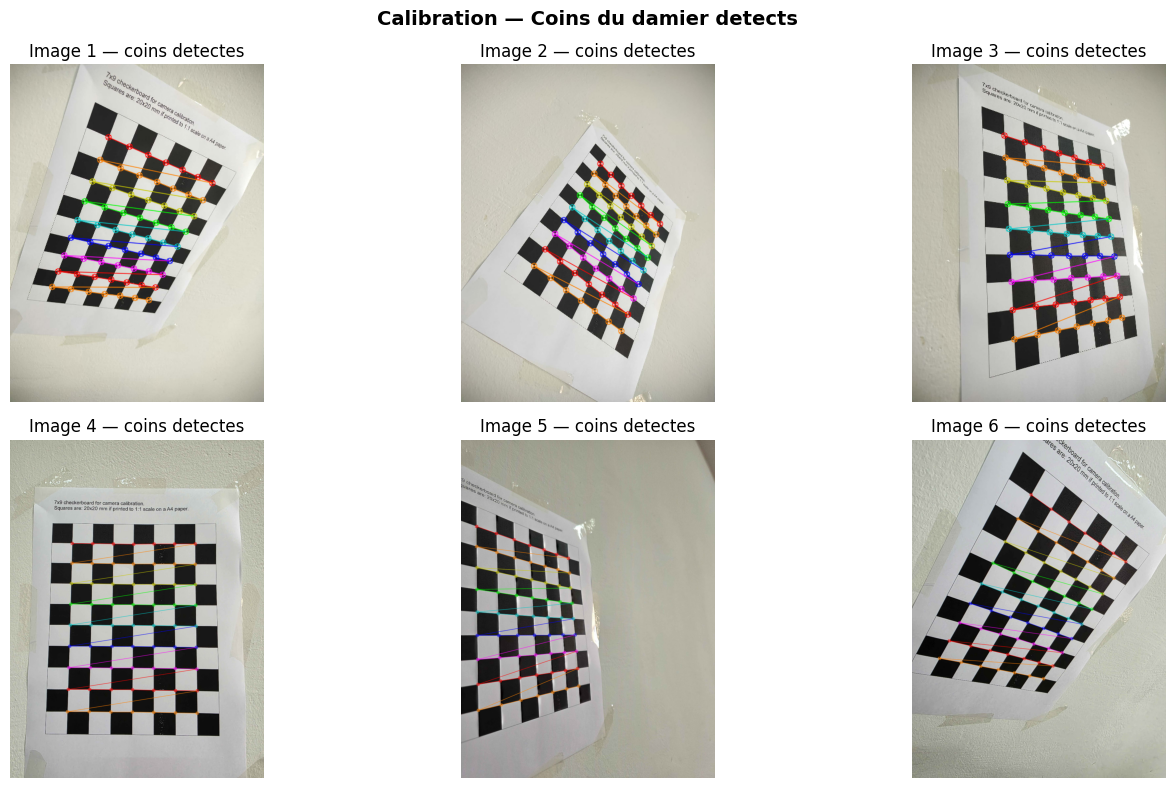

In [114]:
criteres = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Coordonnees 3D theoriques des coins du damier (plan Z=0)
objp = np.zeros((NB_COINS_X * NB_COINS_Y, 3), np.float32)
objp[:, :2] = np.mgrid[0:NB_COINS_X, 0:NB_COINS_Y].T.reshape(-1, 2)
objp *= TAILLE_CASE

objpoints = []  # points 3D reels
imgpoints = []  # points 2D detectes en pixels

images = glob.glob(DOSSIER_CALIBRATION)
print(f'{len(images)} images de calibration trouvees')
if len(images) == 0:
    raise FileNotFoundError(f"Aucune image trouvee dans '{DOSSIER_CALIBRATION}'")

nb_valides = 0
exemples   = []  # pour affichage

for fname in images:
    img  = cv2.imread(fname)
    img  = cv2.resize(img, (0,0), fx=SHRINK_CALIB, fy=SHRINK_CALIB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, coins = cv2.findChessboardCorners(gray, (NB_COINS_X, NB_COINS_Y), None)
    if ret:
        nb_valides += 1
        coins = cv2.cornerSubPix(gray, coins, (11,11), (-1,-1), criteres)
        objpoints.append(objp)
        imgpoints.append(coins)
        if len(exemples) < 6:  # garder 6 exemples pour affichage
            affichage = cv2.drawChessboardCorners(img.copy(), (NB_COINS_X, NB_COINS_Y), coins, ret)
            exemples.append(cv2.cvtColor(affichage, cv2.COLOR_BGR2RGB))

print(f'Damier detecte dans {nb_valides}/{len(images)} images')

# Affichage des images de calibration valides
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(exemples):
        ax.imshow(exemples[i])
        ax.set_title(f'Image {i+1} — coins detectes')
    ax.axis('off')
plt.suptitle('Calibration — Coins du damier detects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('calib_exemples.png', dpi=120, bbox_inches='tight')
plt.show()

In [121]:
# Calcul de la matrice K
h, w = gray.shape
ret_calib, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, (w, h), None, None)

# Calcul de l'erreur de reprojection par image
erreur_totale = 0
for i in range(len(objpoints)):
    pts_repr, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, dist)
    erreur_totale += cv2.norm(imgpoints[i], pts_repr, cv2.NORM_L2) / len(pts_repr)

print('=' * 45)
print('  RESULTATS CALIBRATION')
print('=' * 45)
print(f'  fx = {K[0,0]:.2f} px     fy = {K[1,1]:.2f} px')
print(f'  cx = {K[0,2]:.2f} px     cy = {K[1,2]:.2f} px')
print(f'  Erreur moyenne / image  : {erreur_totale/len(objpoints):.4f} px')
print('=' * 45)

os.makedirs('camera_params', exist_ok=True)
np.save('camera_params/K.npy', K)
np.save('camera_params/dist.npy', dist)
print('  K et dist sauvegardes dans camera_params/')

  RESULTATS CALIBRATION
  fx = 827.57 px     fy = 826.80 px
  cx = 422.74 px     cy = 437.67 px
  Erreur moyenne / image  : 0.4460 px
  K et dist sauvegardes dans camera_params/


---
## Cellule 3 — Étape 2 : Détection SIFT et Mise en correspondance


 SIFT → BFMatcher → Ratio test de Lowe (0.8) → RANSAC

ratio = SHRINK_STEREO / SHRINK_CALIB = 0.8 / 0.3 = 2.67
fx : 827.6 => 2206.8 px
Keypoints : 6001 (photo1)   6001 (photo2)


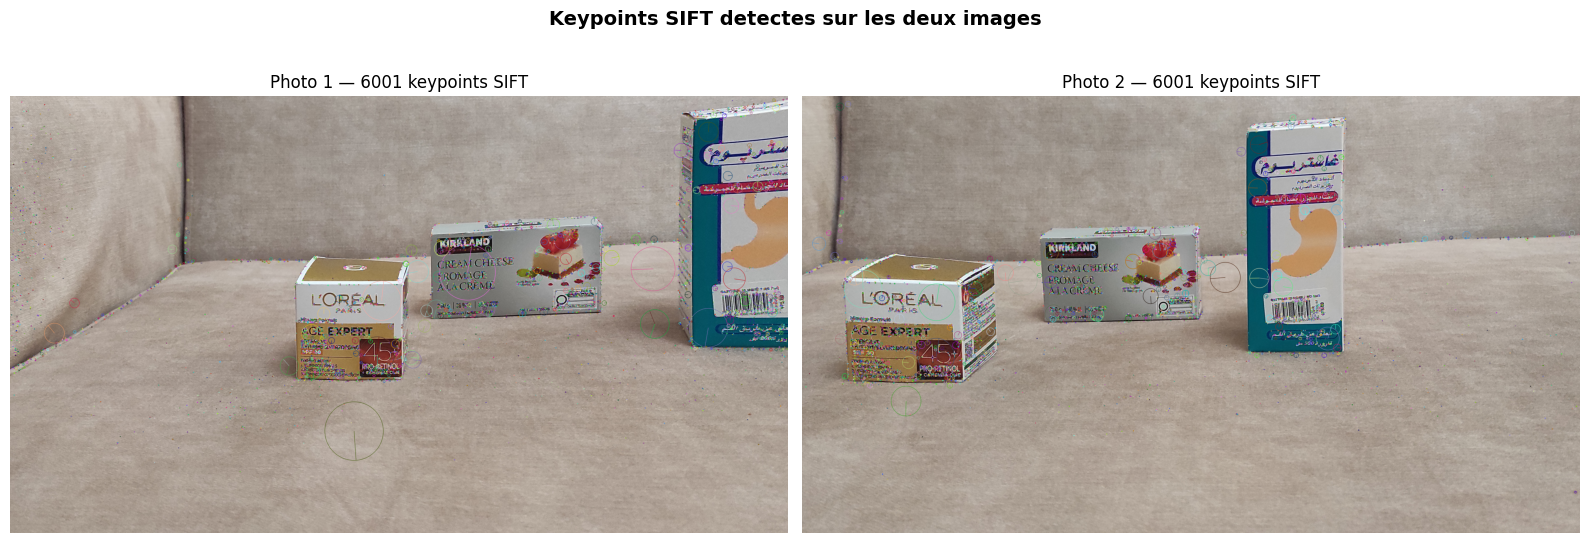

In [116]:
# Chargement et redimensionnement des photos stereo
img1_color = cv2.imread(PHOTO_1)
img2_color = cv2.imread(PHOTO_2)
if img1_color is None or img2_color is None:
    raise FileNotFoundError(f"Impossible de lire '{PHOTO_1}' ou '{PHOTO_2}'")

img1_color = cv2.resize(img1_color, (0,0), fx=SHRINK_STEREO, fy=SHRINK_STEREO, interpolation=cv2.INTER_CUBIC)
img2_color = cv2.resize(img2_color, (0,0), fx=SHRINK_STEREO, fy=SHRINK_STEREO, interpolation=cv2.INTER_CUBIC)

# Adaptation de K : K calibree avec SHRINK_CALIB, images stereo a SHRINK_STEREO
ratio    = SHRINK_STEREO / SHRINK_CALIB
K_scaled = K.copy()
K_scaled[0, 0] *= ratio  # fx
K_scaled[1, 1] *= ratio  # fy
K_scaled[0, 2] *= ratio  # cx
K_scaled[1, 2] *= ratio  # cy

print(f'ratio = SHRINK_STEREO / SHRINK_CALIB = {SHRINK_STEREO} / {SHRINK_CALIB} = {ratio:.2f}')
print(f'fx : {K[0,0]:.1f} => {K_scaled[0,0]:.1f} px')

# Correction de la distorsion optique
img1_color = cv2.undistort(img1_color, K_scaled, dist)
img2_color = cv2.undistort(img2_color, K_scaled, dist)

gray1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)

# Detection SIFT
sift = cv2.SIFT_create(nfeatures=6000, contrastThreshold=0.02)
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)
print(f'Keypoints : {len(kp1)} (photo1)   {len(kp2)} (photo2)')

# Affichage des keypoints
img1_kp = cv2.drawKeypoints(img1_color, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp = cv2.drawKeypoints(img2_color, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
concat  = np.hstack((img1_kp, img2_kp))

cv2.imwrite('output_1_sift_keypoints.jpg', concat)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(img1_kp, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Photo 1 — {len(kp1)} keypoints SIFT', fontsize=12)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2_kp, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Photo 2 — {len(kp2)} keypoints SIFT', fontsize=12)
axes[1].axis('off')
plt.suptitle('Keypoints SIFT detectes sur les deux images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Matches apres ratio test de Lowe (0.8) : 1639
Matches apres RANSAC (inliers) : 1058


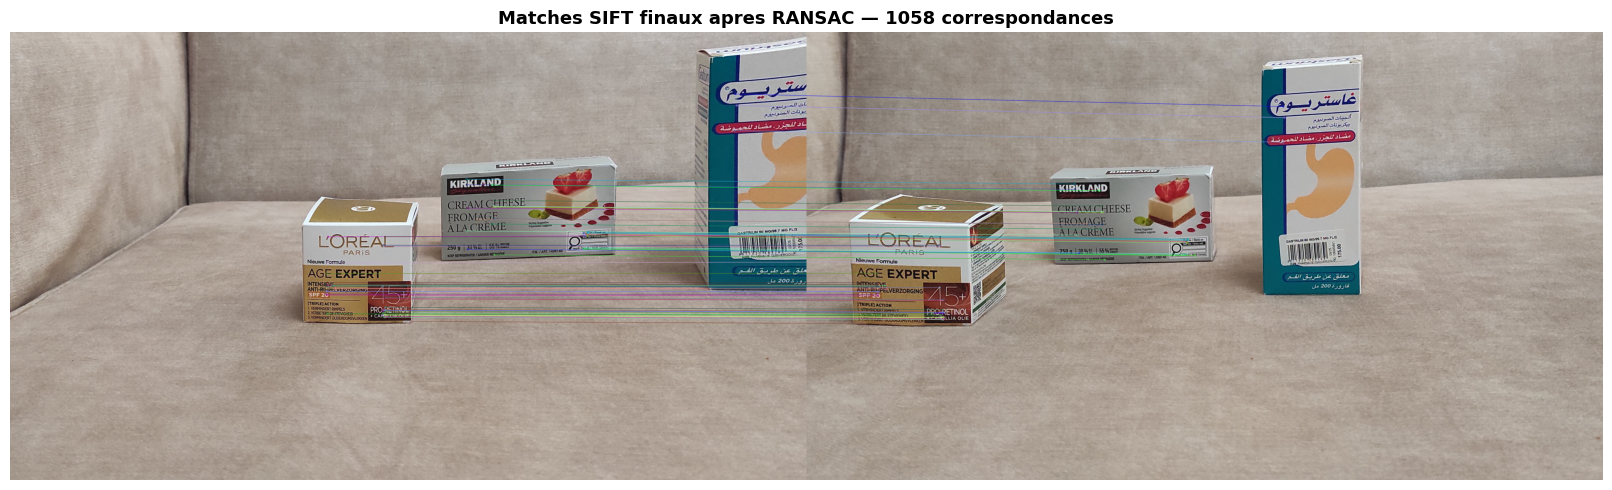

In [ ]:
# Matching par force brute + ratio test de Lowe
bf      = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good, pts1, pts2 = [], [], []
for m, n in matches:
    if m.distance < 0.8 * n.distance:
        good.append([m])
        pts1.append(kp1[m.queryIdx].pt)
        pts2.append(kp2[m.trainIdx].pt)

print(f'Matches apres ratio test de Lowe (0.8) : {len(good)}')

pts1 = np.float32(pts1)
pts2 = np.float32(pts2)

# RANSAC ykhdm geometrique 
F, masque = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 3.0, 0.99)
masque    = masque.ravel()
pts1      = pts1[masque == 1]
pts2      = pts2[masque == 1]

print(f'Matches apres RANSAC (inliers) : {len(pts1)}')

# Affichage des matches finaux
inliers   = [[m[0]] for j, m in enumerate(good) if j < len(masque) and masque[j] == 1]
img_match = cv2.drawMatchesKnn(img1_color, kp1, img2_color, kp2, inliers[:80], None, flags=2)

cv2.imwrite('output_2_sift_matches.jpg', img_match)

plt.figure(figsize=(18, 5))
plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
plt.title(f'Matches SIFT finaux apres RANSAC — {len(pts1)} correspondances', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show() 

---
## Cellule 4 — Étape 3 : Triangulation 3D

** calculer les coordonnées (X, Y, Z) de chaque paire de points



In [ ]:
# Camera 1 : a l'origine
P1 = K_scaled @ np.hstack((np.eye(3), np.zeros((3,1))))

# Camera 2 : deplacee de BASELINE cm sur l'axe X
t2 = np.array([[-BASELINE], [0], [0]])
P2 = K_scaled @ np.hstack((np.eye(3), t2))

print(f'Baseline : {BASELINE} cm')
print(f'Paires a trianguler : {len(pts1)}')
print()
print('P1 (camera 1) :')
print(np.round(P1, 1))
print()
print('P2 (camera 2) :')
print(np.round(P2, 1))

# triangulatePoints attend des tableaux (2, N) => transposition
points4D = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)

# Conversion coordonnees homogenes [X,Y,Z,W] -> cartesiennes [X/W, Y/W, Z/W]
points3D = (points4D[:3] / points4D[3]).T

print(f'\nPoints 3D calcules : {len(points3D)}')
print(f'Z moyen brut : {np.mean(points3D[:,2]):.1f} cm')

# Filtrage 1 : garder les points devant la camera (Z > 0)
points3D = points3D[points3D[:, 2] > 0]

# Filtrage 2 : IQR — eliminer les outliers de profondeur
Z        = points3D[:, 2]
Q1, Q3   = np.percentile(Z, 25), np.percentile(Z, 75)
IQR      = Q3 - Q1
points3D = points3D[(Z > Q1 - 1.5*IQR) & (Z < Q3 + 1.5*IQR)]

print(f'Points valides apres filtrage : {len(points3D)}')
print(f'Z min : {np.min(points3D[:,2]):.1f} cm  |  Z max : {np.max(points3D[:,2]):.1f} cm')
print(f'Z moyen : {np.mean(points3D[:,2]):.1f} cm')

np.save('camera_params/points3D.npy', points3D)

Baseline : 15.0 cm
Paires a trianguler : 1058

P1 (camera 1) :
[[2.2068e+03 0.0000e+00 1.1273e+03 0.0000e+00]
 [0.0000e+00 2.2048e+03 1.1671e+03 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]]

P2 (camera 2) :
[[ 2.20680e+03  0.00000e+00  1.12730e+03 -3.31027e+04]
 [ 0.00000e+00  2.20480e+03  1.16710e+03  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  1.00000e+00  0.00000e+00]]

Points 3D calcules : 1058
Z moyen brut : 43.6 cm
Points valides apres filtrage : 1058
Z min : 35.3 cm  |  Z max : 65.5 cm
Z moyen : 43.6 cm


---
## Cellule 5 — Étape 4 : Visualisation du nuage de points 3D

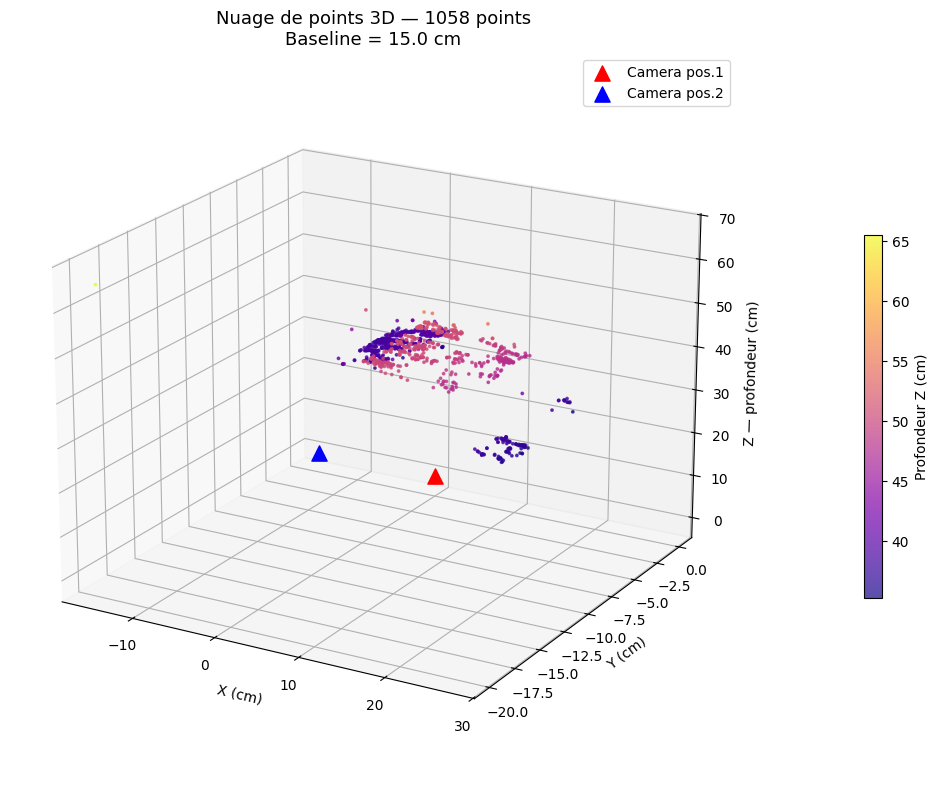

In [119]:
X, Y, Z = points3D[:,0], points3D[:,1], points3D[:,2]

# Vue 3D principale
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(X, Y, Z, c=Z, cmap='plasma', s=3, alpha=0.7)
plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.1).set_label('Profondeur Z (cm)', fontsize=10)
ax.scatter([0],         [0], [0], c='red',  s=120, marker='^', label='Camera pos.1', zorder=5)
ax.scatter([-BASELINE], [0], [0], c='blue', s=120, marker='^', label='Camera pos.2', zorder=5)
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Z — profondeur (cm)')
ax.set_title(f'Nuage de points 3D — {len(points3D)} points\nBaseline = {BASELINE} cm', fontsize=13)
ax.legend()
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.savefig('output_3_nuage_points_3D.png', dpi=150, bbox_inches='tight')
plt.show()

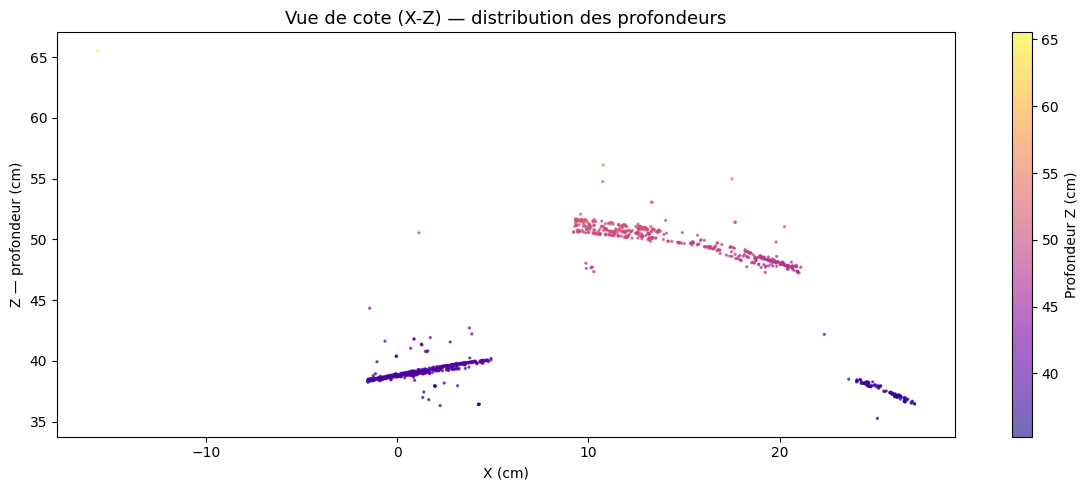

In [120]:
# Vue de cote X-Z
fig2, ax2 = plt.subplots(figsize=(12, 5))
sc2 = ax2.scatter(X, Z, c=Z, cmap='plasma', s=2, alpha=0.6)
plt.colorbar(sc2, ax=ax2).set_label('Profondeur Z (cm)', fontsize=10)
ax2.set_xlabel('X (cm)')
ax2.set_ylabel('Z — profondeur (cm)')
ax2.set_title('Vue de cote (X-Z) — distribution des profondeurs', fontsize=13)
plt.tight_layout()
plt.savefig('output_4_vue_cote.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=X, y=Y, z=Z,
    mode='markers',
    marker=dict(
        size=2,
        color=Z,
        colorscale='Plasma',
        colorbar=dict(title='Z (cm)'),
        opacity=0.8
    )
)])

fig.update_layout(
    title=f'Nuage de points 3D — {len(points3D)} points | Baseline = {BASELINE} cm',
    scene=dict(
        xaxis_title='X (cm)',
        yaxis_title='Y (cm)',
        zaxis_title='Z — profondeur (cm)'
    ),
    width=900,
    height=700
)

fig.show()  # interactif dans Jupyter !